In [1]:
!pip install anndata==0.8.0

In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
import pickle
from scipy.optimize import minimize

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open('parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [4]:
plt_df_raw = pd.read_csv('number_of_mouse_ct_found.csv', index_col = 'Unnamed: 0')

In [ ]:
#Loading Data

In [2]:
fn = '../../Active_SAMap_Joined/active_samap/sm_Allen_Full_dr_cleaned_07172026_ncbi.pkl'
fn_mo = '../../Active_SAMap_Joined/active_samap/sm_mo_03122025_dr_ncbi_cleaned_07172026.pkl'

In [3]:
org = 'dr'
ref_one = 'mg'
ref_two = 'mo'

In [4]:
sm = load_samap(fn)
sm_mo = load_samap(fn_mo)

In [176]:
#setting mo labels to known labels

In [5]:
level = 'fin_ct'

In [6]:
fin_labs = pd.read_csv('../../Active_SAMap_Joined/MO_subclass_id_label_mapping_boostrap_th9_03192025.csv', index_col = 'Unnamed: 0')

In [7]:
len(fin_labs['fin_ct'].unique())

115

In [8]:
len(fin_labs['fin_ct'][fin_labs['fin_ct'] == 'Unlabeled'])

11176

In [9]:
len(fin_labs)

75330

In [10]:
sm_mo.sams['mo'].adata.obs['subclass_id_label_mapping'] = fin_labs['fin_ct']

In [11]:
sm.sams['dr'].adata

AnnData object with n_obs × n_vars = 61430 × 25503
    obs: 'n_genes', 'n_counts', 'key', 'leiden_clusters_neuron', 'leiden_clusters'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions', 'mean_correction'
    uns: 'dimred_indices', 'preprocess_args', 'ranked_genes', 'run_args', 'path_to_file'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_umap', 'X_umap_samap'
    varm: 'PCs', 'PCs_SAMap'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [12]:
sm_mo.sams['dr'].adata

AnnData object with n_obs × n_vars = 61430 × 25503
    obs: 'n_genes', 'n_counts', 'key', 'leiden_clusters_neuron', 'leiden_clusters'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions', 'mean_correction'
    uns: 'dimred_indices', 'preprocess_args', 'ranked_genes', 'run_args', 'path_to_file'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_umap', 'X_umap_samap'
    varm: 'PCs', 'PCs_SAMap'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [13]:
sm.sams['mg'].adata

AnnData object with n_obs × n_vars = 78182 × 32285
    obs: 'Unnamed: 0', 'barcoded_cell_sample_label', 'brain_section_label', 'cell_barcode', 'cell_label', 'class_id_label', 'cluster_alias', 'dataset_label', 'donor_genotype', 'donor_label', 'donor_sex', 'entity', 'feature_matrix_label', 'library_label', 'library_method', 'obs_names', 'region_of_interest_acronym', 'subclass_id_label', 'supertype_id_label', 'x', 'y', 'leiden_clusters'
    var: 'var_names', 'x', 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions', 'mean_correction'
    uns: 'dimred_indices', 'preprocess_args', 'ranked_genes', 'run_args', 'path_to_file'
    obsm: 'X_pca', 'X_processed', 'X_umap', 'X_umap_samap'
    varm: 'PCs', 'PCs_SAMap'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [14]:
sm_mo.sams['mo'].adata

AnnData object with n_obs × n_vars = 75330 × 19307
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes', 'key', 'subclass_id_label_mapping', 'subclass_id_label_lc', 'leiden_clusters', 'subclass_id_label_mapping_nounlabeled', 'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping', 'subclass_id_label_reduced_lc', 'subclass_id_label_reduced_mapping_nounlabeled', 'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'NN', 'ss_subclass', 'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026', 'ss_subclass_nounlabeled_03102026_crossed', 'neurotransmitter_v2'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions', 'mean_correction'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'rank_genes_groups', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', '

In [ ]:
#mapping 

5
77
12
25.006810188293457 seconds to complete 6 precent
10
101
14
51.130691051483154 seconds to complete 13 precent
15
106
12
77.66883897781372 seconds to complete 20 precent
20
116
13
105.22167038917542 seconds to complete 26 precent
25
125
13
133.94154262542725 seconds to complete 33 precent
30
133
14
163.0979232788086 seconds to complete 40 precent
35
132
15
192.80211305618286 seconds to complete 46 precent
40
139
16
223.54153275489807 seconds to complete 53 precent
45
139
16
254.83685994148254 seconds to complete 60 precent
50
144
15
286.88225388526917 seconds to complete 66 precent
55
146
17
319.9525988101959 seconds to complete 73 precent
60
149
18
353.7530987262726 seconds to complete 80 precent
65
147
16
388.2906537055969 seconds to complete 86 precent
70
154
18
423.47036027908325 seconds to complete 93 precent
75
156
19
459.35678339004517 seconds to complete 100 precent


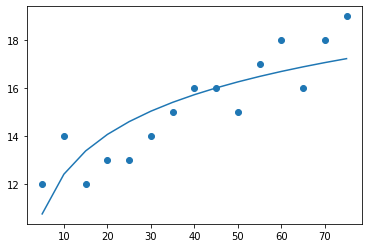

In [15]:
level = 'subclass_id_label'
num_cell_types = []
t0 = time.time()
for reso in range(5,80,5):
    print(reso)
    #clustering the mg to org data
    sm.sams[org].clustering(param = reso)

    # mapping from mg to org data
    keys = {ref_one:level,org:'leiden_clusters'}
    D,MappingTable = get_mapping_scores(sm,keys)
    lim_MappingTable = MappingTable.filter(like=org + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(ref_one)]

    mapping_dict = {}
    for item in lim_MappingTable:
        len_item = len(sm.sams[org].adata[sm.sams[org].adata.obs['leiden_clusters'] == int(item[3:])])
        if len_item > 25:
            mapping_dict[item] = str(lim_MappingTable[item].idxmax())
        else:
            mapping_dict[item] = ref_one + '_Unlabeled'

    #saving new mapping as "temp mapping"
    new_mapping = []
    for item in sm.sams[org].adata.obs['leiden_clusters']:
        new_mapping.append(mapping_dict[org + '_' + str(item)][3:])

    sm_mo.sams[org].adata.obs['temp_mapping'] = new_mapping

    #testing line
    print(sm_mo.sams[org].adata.obs['temp_mapping'].nunique())

    #mapping the mg to org data to the mo data
    keys = {ref_two: level + '_mapping',org:'temp_mapping'}
    D,MappingTable = get_mapping_scores(sm_mo,keys)
    lim_MappingTable = MappingTable.filter(like=org + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(ref_two)]

    #collecting best mappings
    mapping_dict = {}
    for item in lim_MappingTable:
        mapping_dict[item] = str(lim_MappingTable[item].idxmax())


    #checking whether the best mapping is the same in mo and mg
    mapping_dict_mo = {item:'Unlabeled' for item in mapping_dict}
    for item in mapping_dict:
        if item[3:] == mapping_dict[item][3:]:
            mapping_dict_mo[item] = mapping_dict[item][3:]

    #saving the new mapping
    new_mapping_mo = []
    for item in sm_mo.sams[org].adata.obs['temp_mapping']:
        new_mapping_mo.append(mapping_dict_mo[org + '_' + item])

    #testing line
    print(len(set(new_mapping_mo)))

    #finding the "highest quality mapping across resolutions and saving it
    sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(reso)] = new_mapping_mo
    sm.sams[org].adata.obs['temp_mapping_lc_reso_' + str(reso)] = sm.sams[org].adata.obs['leiden_clusters']
    num_cell_types.append(sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(reso)].nunique())

    t1 = time.time()
    print(str(t1 - t0) + ' seconds to complete ' + str(int((reso/5)*(100/15))) + ' precent')

x = [i for i in range(5,80,5)]
func = np.polyfit(np.log(x), num_cell_types, 1)
plt.plot([i for i in range(5,80,5)], [func[0] * np.log(i) + func[1] for i in range(5,80,5)])
plt.scatter(x, num_cell_types)
plt.show()

In [16]:
sm.sams['dr'].adata.obs

,n_genes,n_counts,key,leiden_clusters_neuron,leiden_clusters,temp_mapping_subclass_id_label_reso_5,temp_mapping_lc_reso_5,temp_mapping_subclass_id_label_reso_10,temp_mapping_lc_reso_10,temp_mapping_subclass_id_label_reso_15,...,temp_mapping_subclass_id_label_reso_55,temp_mapping_lc_reso_55,temp_mapping_subclass_id_label_reso_60,temp_mapping_lc_reso_60,temp_mapping_subclass_id_label_reso_65,temp_mapping_lc_reso_65,temp_mapping_subclass_id_label_reso_70,temp_mapping_lc_reso_70,temp_mapping_subclass_id_label_reso_75,temp_mapping_lc_reso_75
AAACCTGAGAGTTGGC,496,866.0,DarioRerio1,Nonneuron,163,Unlabeled,11,Unlabeled,75,Unlabeled,...,Unlabeled,87,Unlabeled,83,Unlabeled,95,Unlabeled,83,Unlabeled,163
AAACCTGAGGTGACCA,491,618.0,DarioRerio1,16,65,Unlabeled,43,Unlabeled,31,Unlabeled,...,Unlabeled,12,Unlabeled,2,Unlabeled,26,Unlabeled,22,Unlabeled,65
AAACCTGCAAGCGTAG,774,1502.0,DarioRerio1,Nonneuron,82,Unlabeled,19,Unlabeled,10,Unlabeled,...,Unlabeled,185,Unlabeled,200,Unlabeled,368,Unlabeled,402,Unlabeled,82
AAACCTGCAGTAGAGC,929,1417.0,DarioRerio1,20,65,Unlabeled,43,Unlabeled,31,Unlabeled,...,Unlabeled,12,Unlabeled,2,Unlabeled,26,Unlabeled,22,Unlabeled,65
AAACCTGCATCACCCT,702,1262.0,DarioRerio1,Nonneuron,83,Unlabeled,30,Unlabeled,23,Unlabeled,...,Unlabeled,122,Unlabeled,78,Unlabeled,145,Unlabeled,158,Unlabeled,83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCACACACCGCA,658,1277.0,DanioRerio16,15,480,Unlabeled,28,Unlabeled,39,Unlabeled,...,Unlabeled,446,Unlabeled,440,Unlabeled,435,Unlabeled,488,Unlabeled,480
TTTGTCACATGTAAGA,2099,8522.0,DanioRerio16,Nonneuron,303,Unlabeled,19,Unlabeled,10,Unlabeled,...,Unlabeled,194,Unlabeled,260,Unlabeled,293,Unlabeled,248,Unlabeled,303
TTTGTCACATTATCTC,945,1461.0,DanioRerio16,14,25,057 NDB-SI-MA-STRv Lhx8 Gaba,26,Unlabeled,91,Unlabeled,...,Unlabeled,10,Unlabeled,21,Unlabeled,13,Unlabeled,27,Unlabeled,25
TTTGTCAGTCCGAGTC-2,1271,2548.0,DanioRerio16,10,527,Unlabeled,44,Unlabeled,27,Unlabeled,...,Unlabeled,309,Unlabeled,134,Unlabeled,132,Unlabeled,140,086 MPO-ADP Lhx8 Gaba,527


In [17]:
#set value
best_reso = 60

print(best_reso)
sm.sams[org].adata.obs[level + '_mapping'] = sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(best_reso)]
sm.sams[org].adata.obs[level + '_lc'] = sm.sams[org].adata.obs['temp_mapping_lc_reso_' + str(best_reso)]
for reso in range(5,80,5):
    print(reso == best_reso)
    if reso != best_reso: 
        sm.sams[org].adata.obs = sm.sams[org].adata.obs.drop('temp_mapping_' + level + '_reso_' + str(reso), axis = 1)
        sm.sams[org].adata.obs = sm.sams[org].adata.obs.drop('temp_mapping_lc_reso_' + str(reso), axis = 1)
        
sm.sams[org].adata.obs.to_csv('../../Active_SAMap_Joined/' + org.upper() + '_metadata_subclass_250_0_07162026.csv')

60
False
False
False
False
False
False
False
False
False
False
False
True
False
False
False


In [21]:
sm.sams['dr'].adata.obs['subclass_id_label_lc'].to_csv('Test_resolution60_DR_cleaned_07172026.csv')

In [45]:
for i in range(1,30):
    num_ct_mapped = 0
    t0 = time.time()
    level = 'subclass_id_label'
    num_cell_types = []
    reso = 30
    
    sm = load_samap('sm_Allen_Full_ac_ncbi_soupx_cleaned_03122025_subclass_250_' + str(i)+ '.pkl')
    
    #clustering the mg to org data
    sm.sams[org].clustering(param = reso)

    # mapping from mg to org data
    keys = {ref_one:level,org:'leiden_clusters'}
    D,MappingTable = get_mapping_scores(sm,keys)
    lim_MappingTable = MappingTable.filter(like=org + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(ref_one)]

    mapping_dict = {}
    for item in lim_MappingTable:
        len_item = len(sm.sams[org].adata[sm.sams[org].adata.obs['leiden_clusters'] == int(item[3:])])
        if len_item > 25:
            mapping_dict[item] = str(lim_MappingTable[item].idxmax())
        else:
            mapping_dict[item] = ref_one + '_Unlabeled'

    #saving new mapping as "temp mapping"
    new_mapping = []
    for item in sm.sams[org].adata.obs['leiden_clusters']:
        new_mapping.append(mapping_dict[org + '_' + str(item)][3:])

    sm_mo.sams[org].adata.obs['temp_mapping'] = new_mapping

    #testing line
    print(sm_mo.sams[org].adata.obs['temp_mapping'].nunique())

    #mapping the mg to org data to the mo data
    keys = {ref_two: level + '_mapping',org:'temp_mapping'}
    D,MappingTable = get_mapping_scores(sm_mo,keys)
    lim_MappingTable = MappingTable.filter(like=org + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(ref_two)]

    #collecting best mappings
    mapping_dict = {}
    for item in lim_MappingTable:
        mapping_dict[item] = str(lim_MappingTable[item].idxmax())


    #checking whether the best mapping is the same in mo and mg
    mapping_dict_mo = {item:'Unlabeled' for item in mapping_dict}
    for item in mapping_dict:
        if item[3:] == mapping_dict[item][3:]:
            mapping_dict_mo[item] = mapping_dict[item][3:]

    #saving the new mapping
    new_mapping_mo = []
    for item in sm_mo.sams[org].adata.obs['temp_mapping']:
        new_mapping_mo.append(mapping_dict_mo[org + '_' + item])

    #testing line
    print(len(set(new_mapping_mo)))

    #finding the "highest quality mapping across resolutions and saving it
    sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(reso)] = new_mapping_mo
    sm.sams[org].adata.obs['temp_mapping_lc_reso_' + str(reso)] = sm.sams[org].adata.obs['leiden_clusters']
    num_cell_types.append(sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(reso)].nunique())

    t1 = time.time()
    print(str(t1 - t0) + ' seconds to complete ' + f"{i/30:.2f}" + ' precent')

    sm.sams[org].adata.obs[level + '_mapping'] = sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(reso)]
    sm.sams[org].adata.obs[level + '_lc'] = sm.sams[org].adata.obs['temp_mapping_lc_reso_' + str(reso)]
    sm.sams[org].adata.obs = sm.sams[org].adata.obs.drop('temp_mapping_' + level + '_reso_' + str(reso), axis = 1)
    sm.sams[org].adata.obs = sm.sams[org].adata.obs.drop('temp_mapping_lc_reso_' + str(reso), axis = 1)
    sm.sams[org].adata.obs.to_csv('AC_metadata_'+str(i) +'_test.csv')

153
61
121.48477172851562 seconds to complete 0.03 precent
